# Lab: Relationships in Space and Time

Florida red tide is caused primarily by high concentrations of the microscopic alga *Karenia brevis*. The organism can produce toxins that harm marine life and cause respiratory irritation near affected shorelines. A bloom does not remain in one fixed place: winds and currents can move and disperse it while its concentration changes.

This lab examines part of the unusually long 2017–2019 Florida red-tide bloom. From June through November 2018, documented bloom concentrations expanded beyond southwest Florida and were detected in the Panhandle and, for part of the period, along the Atlantic coast.

## Learning goals

By the end of this lab, you should be able to:

- prepare and check a temporal feature;
- summarize observations by month;
- create and interpret an interactive time-series plot;
- map observations using exact latitude and longitude coordinates;
- animate spatial observations through time with Plotly Express; and
- distinguish documented sample locations from the complete extent of an environmental event.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The course dataset was prepared from the Florida Fish and Wildlife Conservation Commission's [Historic Harmful Algal Bloom Events 2015–2023 GIS layer](https://gis.myfwc.com/mapping/rest/services/Open_Data/Historic_Harmful_Algal_Bloom_Events_2015___2023/MapServer/12). It contains **7,292 water samples** collected from June 1 through November 30, 2018.

These are sampling records, not a continuous measurement of every part of Florida's coastal water. Sampling included routine monitoring, research, and additional event-response sampling when a bloom was suspected or already known.

# Step 1: Question

> **How did the location and concentration of documented Florida red tide change from June through November 2018?**

**During which month do you predict the greatest share of samples reached bloom concentration?**

Your answer: I predict maybe September will be the greatest share of samples. Right at the end of summer just in time for the "cold" months of Florida. 

**Where around Florida do you predict bloom concentrations will appear by the end of this period?**

Your answer: Based on the info provided, the Southwest then into the Panhandle along the Atlantic coast. 

# Step 2: Data

## 1. Import the libraries

Import Pandas and Plotly Express using their conventional aliases.

In [73]:
# Write your code here.
import pandas as pd
import plotly.express as px

## 2. Read the data

Read `data/florida_red_tide_samples_june_november_2018.csv` into a DataFrame named `red_tide`. Use `parse_dates=["sample_date"]` so Pandas stores the sample date as a datetime rather than text.

In [74]:
# Write your code here.
red_tide = pd.read_csv('data/florida_red_tide_samples_june_november_2018.csv', parse_dates=["sample_date"])

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [75]:
# Write your code here.
red_tide.head()

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.36043,-80.06847,0.5,0.0,Not present/background
1,2018-06-01,Gumbo Limbo Nature Center (Lake Wyman),26.36751,-80.07118,0.5,0.0,Not present/background
2,2018-06-01,Bay Dock (Sarasota Bay),27.33160,-82.57790,0.5,5000.0,Very low
3,2018-06-01,New Pass Dock (Sarasota Bay),27.33375,-82.57938,0.5,1000.0,Not present/background
4,2018-06-01,Dixie Highway Bridge; E of (Indian River),27.85566,-80.49085,1.3,0.0,Not present/background


In [76]:
red_tide.tail()

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
7287,2018-11-29,Brooks Bridge; W of (Santa Rosa Sound),30.400800,-86.600800,0.1,0.0,Not present/background
7288,2018-11-30,Gasparilla Island; 10 mi W of,26.722583,-82.366933,0.5,20667.0,Low
7289,2018-11-30,Gasparilla Island; 13 mi W of,26.760700,-82.475550,0.5,391020.0,Medium
7290,2018-11-30,Bay Dock (Sarasota Bay),27.331600,-82.577900,0.5,534000.0,Medium
7291,2018-11-30,New Pass Dock (Sarasota Bay),27.333750,-82.579380,0.5,274000.0,Medium


In [77]:
red_tide.info()

<class 'pandas.DataFrame'>
RangeIndex: 7292 entries, 0 to 7291
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   sample_date                     7292 non-null   datetime64[us]
 1   location                        7292 non-null   str           
 2   latitude                        7292 non-null   float64       
 3   longitude                       7292 non-null   float64       
 4   sample_depth_m                  7259 non-null   float64       
 5   karenia_brevis_cells_per_liter  7292 non-null   float64       
 6   abundance_category              7292 non-null   str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 714.8 KB


In [78]:
red_tide.isnull().sum()

sample_date                        0
location                           0
latitude                           0
longitude                          0
sample_depth_m                    33
karenia_brevis_cells_per_liter     0
abundance_category                 0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `sample_date` | Calendar date on which the water sample was collected |
| `location` | Description or name of the sampling location |
| `latitude` | Sample latitude in decimal degrees north |
| `longitude` | Sample longitude in decimal degrees; values west of the prime meridian are negative |
| `sample_depth_m` | Sampling depth in meters |
| `karenia_brevis_cells_per_liter` | Number of *Karenia brevis* cells measured per liter of water |
| `abundance_category` | FWC concentration category calculated from the cell count |

The FWC categories are:

- **Not present/background:** 0–1,000 cells per liter
- **Very low:** over 1,000–10,000
- **Low:** over 10,000–100,000
- **Medium:** over 100,000–1,000,000
- **High:** over 1,000,000

For this lab, a sample is at **bloom concentration** when it contains at least 100,000 cells per liter.

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `sample_date` | `temporal` | `datetime64` | `0` |
| `location` | `categorical` | `str` | `0` |
| `latitude` | `quantitative` | `float64` | `0` |
| `longitude` | `quantitative` | `float64` | `0` |
| `sample_depth_m` | `quantitative` | `float64` | `33` |
| `karenia_brevis_cells_per_liter` | `quantitative` | `float64` | `0` |
| `abundance_category` | `categorical` | `str` | `0` |

**What does one row represent?**

Your answer: Each row represents one water sample collected and tested on a specific date at a specific location.

**Why can the same location appear in more than one row?**

Your answer: It appears this is a dataset based on time so, researchers may return to the exact same location on different days (or even different times on the same day) to collect a new water sample and measure how the red tide concentration has changed over time.

# Step 3: Operation

## 4. Sort the samples by date

Sort `red_tide` by `sample_date`. Use `inplace=True` to modify the existing DataFrame rather than creating another one.

In [79]:
# Write your code here.
red_tide.sort_values("sample_date", inplace=True)
red_tide.head()

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.360430,-80.068470,0.5,0.0,Not present/background
8,2018-06-01,Park Point Circle; E of (St. Joseph Bay),29.758450,-85.384433,0.1,0.0,Not present/background
7,2018-06-01,Blacks Island; S of (St. Joseph Bay),29.719033,-85.332683,0.1,0.0,Not present/background
6,2018-06-01,Seahorse Key; 2.5 mi SW of,29.081320,-83.110200,0.5,0.0,Not present/background
5,2018-06-01,Seahorse Key; 8.4 mi SW of,29.023130,-83.180870,0.5,0.0,Not present/background


## 5. Create monthly time features

Create `month` by using datetime methods to convert each `sample_date` to a monthly period and then back to a timestamp. The resulting timestamp represents the first day of its month and can be sorted chronologically.

Then create `month_label` with `.dt.strftime("%B %Y")`. This creates readable labels such as `June 2018` for the animation.

In [80]:
# Write your code here.
red_tide['month'] = red_tide['sample_date'].dt.to_period('M').dt.to_timestamp() #note to self you had to look this one up. 
red_tide['month_label'] = red_tide['sample_date'].dt.strftime('%B %Y')

## 6. Identify samples at bloom concentration

Create a Boolean feature named `bloom_level` that is `True` when `karenia_brevis_cells_per_liter` is at least 100,000 and `False` otherwise.

In [81]:
# Write your code here.
red_tide['bloom_level'] = red_tide['karenia_brevis_cells_per_liter'] >= 100000

## 7. Create a monthly summary

Group the records by `month` and use `.agg()` to calculate:

- `total_samples`: the number of cell-count records in each month; and
- `bloom_samples`: the sum of `bloom_level` in each month.

Summing works because Pandas evaluates `True` as 1 and `False` as 0. Use `.reset_index()` to return `month` to a regular column.

Then calculate `percent_bloom` as the number of bloom samples divided by the total number of samples, multiplied by 100. Display `monthly_summary`.

In [82]:
# Write your code here.
monthly_summary = red_tide.groupby('month').agg(
    total_samples=('karenia_brevis_cells_per_liter', 'count'),
    bloom_samples=('bloom_level', 'sum')
).reset_index()

monthly_summary['percent_bloom'] = (monthly_summary['bloom_samples'] / monthly_summary['total_samples']) * 100

monthly_summary

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


## 8. Prepare the map data

To keep the spatial figures readable, create `map_data` containing samples with more than 10,000 cells per liter. Use `.copy()` because `map_data` will be a separate DataFrame used for the figures.

Create `month_order` from the unique `month_label` values. Because the rows were sorted first, the labels will be in chronological order. Also create `abundance_order` containing `Low`, `Medium`, and `High` in that order.

Samples at or below 10,000 cells per liter remain in `red_tide` and in the monthly summary; they are omitted only from the maps.

In [83]:
# Write your code here.
map_data = red_tide[red_tide['karenia_brevis_cells_per_liter']>10000].copy()

month_order = map_data['month_label'].unique().tolist()
abundance_order = ['Low', 'Medium', 'High']

# Step 4: Check

## 9. Check the prepared data

Display:

- the number of rows;
- the earliest and latest dates;
- the number of unique months;
- missing-value counts for the date, coordinates, cell count, and depth; and
- descriptive statistics for latitude, longitude, depth, and cell count.

In [84]:
# Write your code here.
print('Rows:', len(red_tide))
print('Earliest date:', red_tide['sample_date'].min())
print('Latest date:', red_tide['sample_date'].max())
print('Unique months:', red_tide['month_label'].nunique())

print('\nMissing Values:')
print(red_tide[['sample_date', 'latitude', 'longitude', 'karenia_brevis_cells_per_liter', 'sample_depth_m']].isnull().sum())

print('\nDescriptive statistics:')
print(red_tide[['latitude', 'longitude', 'sample_depth_m', 'karenia_brevis_cells_per_liter']].describe().round(1))

Rows: 7292
Earliest date: 2018-06-01 00:00:00
Latest date: 2018-11-30 00:00:00
Unique months: 6

Missing Values:
sample_date                        0
latitude                           0
longitude                          0
karenia_brevis_cells_per_liter     0
sample_depth_m                    33
dtype: int64

Descriptive statistics:
       latitude  longitude  sample_depth_m  karenia_brevis_cells_per_liter
count    7292.0     7292.0          7259.0                          7292.0
mean       27.4      -82.3             1.3                        547263.6
std         1.3        1.5             4.4                       3276337.4
min        24.5      -87.3             0.0                             0.0
25%        26.6      -82.7             0.5                             0.0
50%        27.3      -82.3             0.5                             0.0
75%        28.0      -81.4             0.5                         30667.0
max        30.7      -79.9            71.0                      

**Why do the 33 missing depth values not require us to remove those records from this analysis?**

Your answer: We are investigating how the location and concentration changed over time. Because we are not using the sample_depth_m feature in our research question or mapping, those 33 missing depth values will not affect the analysis. Dropping those records would just delete valid location and concentration data.

## 10. Check the aggregation

Display `monthly_summary`, then compare the sum of `total_samples` with the number of rows in `red_tide`. Compare the sum of `bloom_samples` with the sum of `bloom_level` in the original DataFrame.

In [85]:
# Write your code here.
monthly_summary

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


In [86]:
print('\nSum of total_samples:', monthly_summary['total_samples'].sum())
print('Rows in red_tide:', len(red_tide))

print('\nSum of bloom_samples:', monthly_summary['bloom_samples'].sum())
print('Sum of bloom_level in red_tide:', red_tide['bloom_level'].sum())


Sum of total_samples: 7292
Rows in red_tide: 7292

Sum of bloom_samples: 1426
Sum of bloom_level in red_tide: 1426


**What kind of preparation error could be revealed if either pair of totals did not match?**

Your answer: If the totals did not match, it would indicate that records were dropped or duplicated during the grouping process. Which could happen if there were missing values in the month column causing entire rows to be excluded from the .agg() calculation.

# Step 5: Evidence

## 11. Plot the monthly percentage at bloom concentration

Use `px.line()` with `monthly_summary` to plot `month` against `percent_bloom`. Show markers and add a question-focused title and readable axis labels.

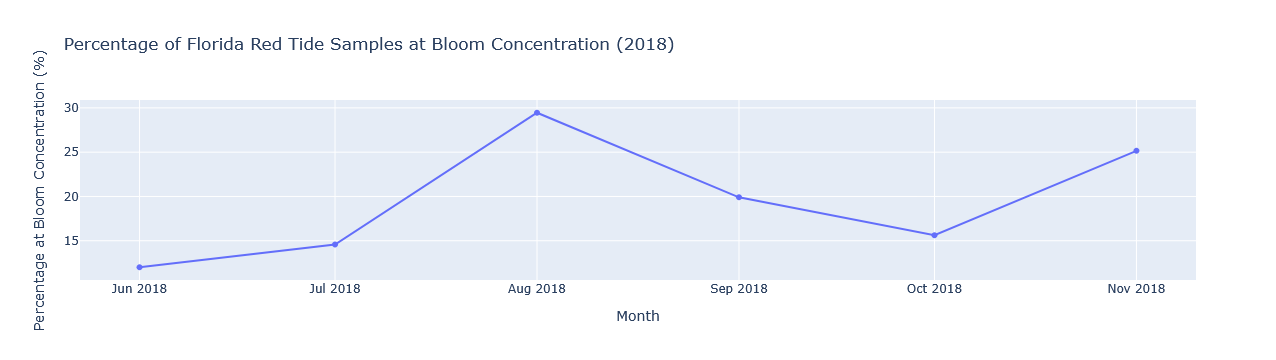

In [87]:
# Write your code here.
bloom_figure = px.line(
    monthly_summary,
    x='month',
    y='percent_bloom',
    markers=True,
    title='Percentage of Florida Red Tide Samples at Bloom Concentration (2018)',
    labels={
        'month': 'Month',
        'percent_bloom': ('Percentage at Bloom Concentration (%)'
        )
    }
)

bloom_figure.show()

**During which month was the percentage of samples at bloom concentration highest?**

Your answer: The percentage of samples at bloom concentration was highest in August 2018.

**What temporal pattern do you observe from June through November?**

Your answer: The percentage of samples at bloom concentration increased sharply from June, peaking in August at 29.449838%. It then rapidly declined through September and October to 15.633423%, before spiking back up to 25.152306% in November.

## 12. Map the documented sample locations

Create a static `px.scatter_map()` using `map_data`.

- Use the exact `latitude` and `longitude` features.
- Map `abundance_category` to color.
- Use `location` as the hover name.
- Include `sample_date` and the cell count in `hover_data`.
- Use `abundance_order` in `category_orders`.
- Choose three ordered colors for Low, Medium, and High abundance.
- Use `zoom=4.5`, center the map at latitude 27.7 and longitude -82.3, use the `open-street-map` style, and set `height=650`.

The `abundance_category` values were already defined in the course dataset from the FWC cell-count ranges introduced in the data dictionary:

- **Low:** over 10,000–100,000 cells per liter
- **Medium:** over 100,000–1,000,000 cells per liter
- **High:** over 1,000,000 cells per liter

Because `map_data` contains only samples above 10,000 cells per liter, these are the three categories that appear in the map legend. You do not need to calculate the categories again.



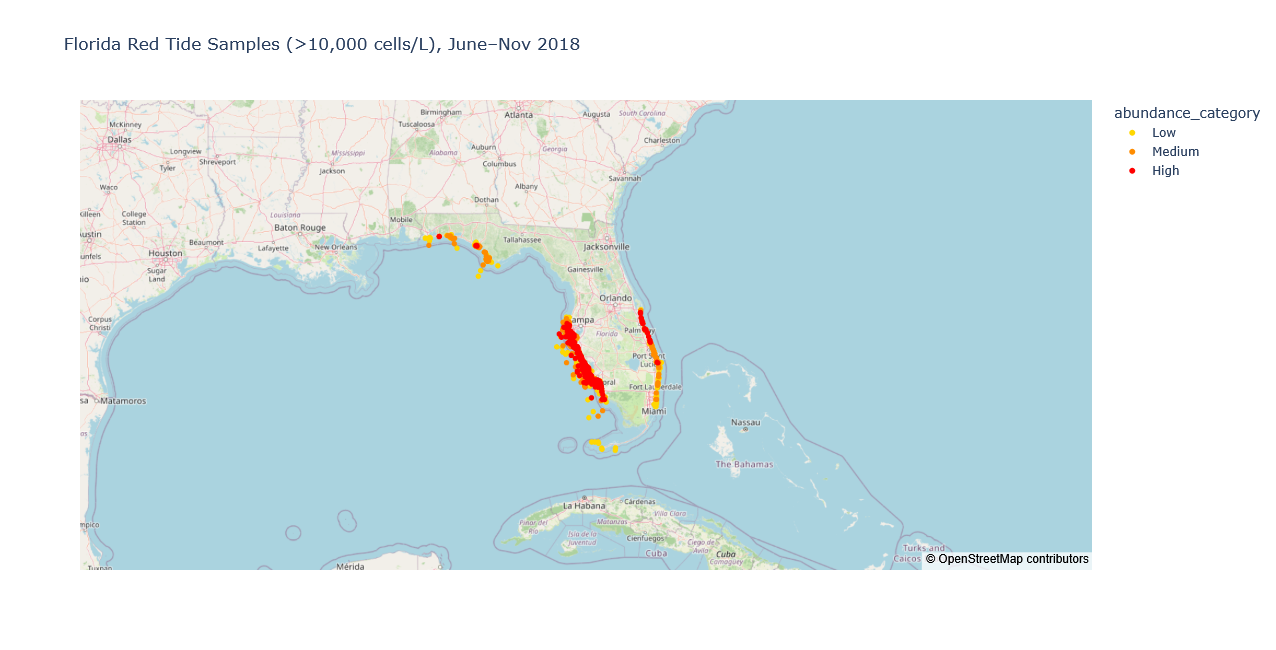

In [88]:
# Write your code here.
bloom_map = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data={
        "sample_date": True,
        "karenia_brevis_cells_per_liter": True
    },
    category_orders={
        "abundance_category": abundance_order
    },
    color_discrete_map={
        "Low": "gold",
        "Medium": "darkorange",
        "High": "red"
    },
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650,
    title="Florida Red Tide Samples (>10,000 cells/L), June–Nov 2018"
)
bloom_map.show()

**What spatial pattern is visible in the static map?**

Your answer: The heaviest and most frequent high-concentration samples are heavily clustered along the southwest coast of Florida. There are also noticeable, though less dense, clusters in the Panhandle and scattered along the Atlantic (east) coast.

**What important temporal information is difficult to recover from the static map?**

Your answer: Because all six months of data are plotted at once, overlapping each other, it is impossible to see when the bloom started, how it spread over time, or during which exact months it reached the Panhandle and Atlantic coasts.

## 13. Animate the documented sample locations

Re-create the spatial figure with `animation_frame="month_label"`. Add the chronological `month_order` to `category_orders` so the slider follows June through November.

Keep the map center, zoom, height, category order, and colors fixed. This makes changes among frames easier to interpret as changes in the observations rather than changes in the display.

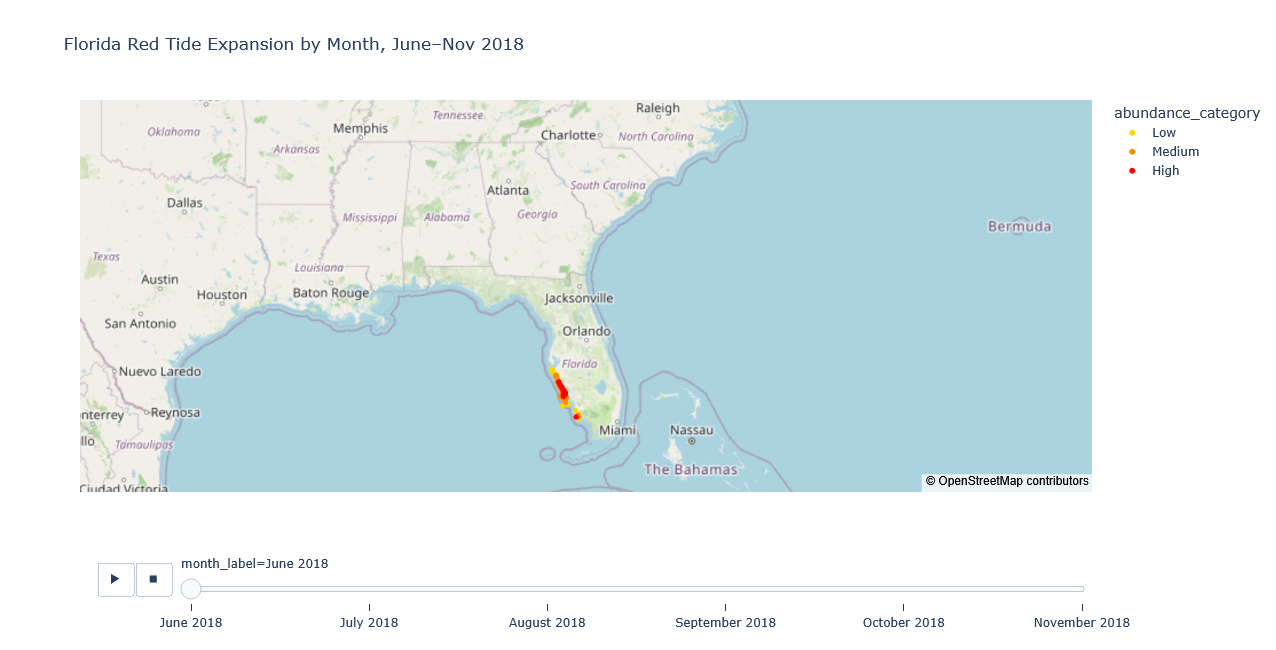

In [89]:
# Write your code here.
bloom_map_animated = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    animation_frame="month_label",
    hover_name="location",
    hover_data={
        "sample_date": True,
        "karenia_brevis_cells_per_liter": True
    },
    category_orders={
        "abundance_category": abundance_order,
        "month_label": month_order
    },
    color_discrete_map={
        "Low": "gold",
        "Medium": "darkorange",
        "High": "red"
    },
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650,
    title="Florida Red Tide Expansion by Month, June–Nov 2018"
)
bloom_map_animated.show()

**How did the documented bloom's geographic pattern change from June through November?**

Your answer: In June and July, the bloom was almost entirely isolated to the southwest Florida coast. By September and October, it rapidly expanded northward into the Panhandle and wrapped around the southern tip to the Atlantic coast. By November, the Atlantic samples faded, leaving the bulk of the bloom concentrated back on the Gulf coasts.

**Which figure makes the timing of geographic expansion easiest to see?**

Your answer: Definitely the animated map. 

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from both the time-series plot and the animated map.**

Your answer: The Florida red tide bloom began isolated on the southwest coast in early summer, with the highest overall percentage of bloom-level samples occurring in August (29.449838%), as seen in the time-series plot. However, the animated map reveals that the geographic footprint expanded significantly in September and October, spreading into the Panhandle and along the Atlantic coast, demonstrating that a bloom's spatial reach can peak or shift even as its overall percentage of severe concentrations fluctuates.

**Why does the animation show documented sample locations rather than the complete geographic boundary of the bloom?**

Your answer: The dataset consists only of point-in-time water samples collected by researchers in specific locations. It is not a continuous measurement (like a doppler radar), so we can only map where a researcher physically pulled a sample, rather than drawing an exact continuous boundary of the entire affected area.

**Why should the monthly percentages not be interpreted as the percentage of all Florida coastal water affected by red tide?**

Your answer: These sampling locations were not completely random or evenly distributed across all Florida waters. Because the data includes "event-response sampling," researchers were likely actively targeting areas where blooms were already suspected or reported, which heavily skews the percentages compared to the true average of all coastal waters.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I did mostly use the lecture notes, but I did use Gemini to check completed work and to help me with my conclusions. I did reject its suggestion to use .min() on question 9 for both the earliest date and the latest date. It gave me a hilarious "You are absolutely right, great catch!" as a response. I did correct my typos and my conclusions to make them flow better.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give every figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Distinguish sample locations from the complete extent of the bloom.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.